# FaunaCodec pipeline demo

This notebook runs each stage of the pipeline separately on the bundled clip, so you can see what every stage produces and how they compose.

**Before running:** install the package and fetch the codec weights.

```bash
bash setup.sh && source .venv/bin/activate
python scripts/download_models.py --group compress decompress
```

The restoration stage additionally needs `--group restore`; it is skipped automatically if the checkpoint is not present.

## Setup

In [1]:
import json
import sys
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from faunacodec import stages
from faunacodec.archive import read_payloads
from faunacodec.masking import boxes_for_frame, build_boxes_mask
from faunacodec.video_io import probe_video, read_video, resize_video

plt.rcParams["figure.dpi"] = 110


def show(images, titles, figsize=(15, 5)):
    "Display BGR frames side by side."
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for ax, image, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def psnr(a, b):
    mse = ((a.astype(np.float64) - b.astype(np.float64)) ** 2).mean()
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


def free_gpu():
    "Each stage loads its own models; release them before the next one allocates."
    import gc

    import torch

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 1. The input

The detector reads the native-resolution recording so small animals retain as much detail as possible. The codec separately operates at the aspect-correct deployment resolution of 640x360; detection boxes are scaled into that coordinate space before the streams are built.

source: VideoInfo(width=1280, height=720, fps=30.0, frame_count=627)


working copy: 627 frames at 30 fps, 640x360


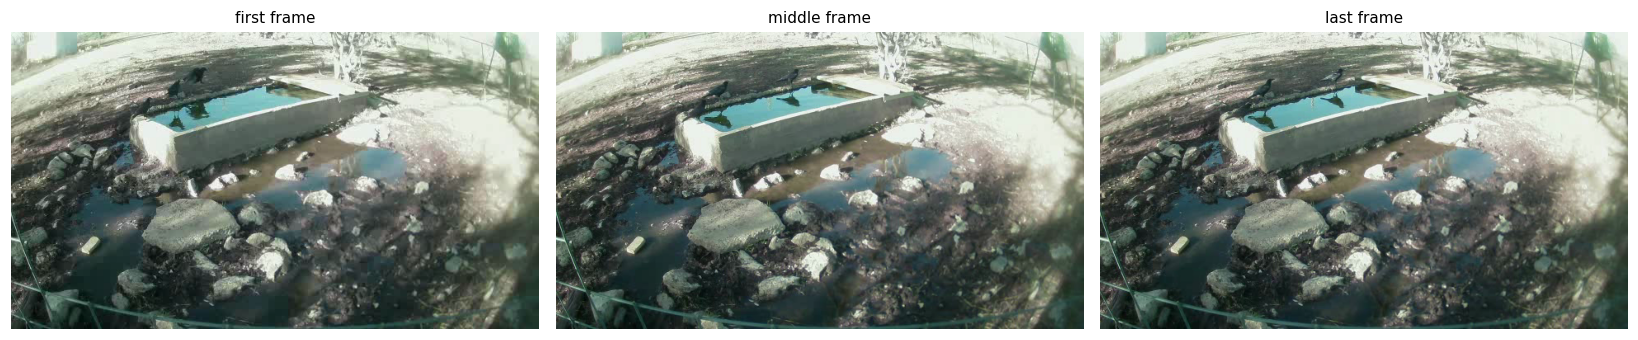

In [2]:
SOURCE = ROOT / "data" / "bird1.mp4"
WORK = ROOT / "outputs" / "notebook_demo"
WORK.mkdir(parents=True, exist_ok=True)

print("source:", probe_video(SOURCE))
video = resize_video(SOURCE, WORK / "input.mp4", 640, 360)
original, fps = read_video(video)
print(f"working copy: {len(original)} frames at {fps:.0f} fps, {original[0].shape[1]}x{original[0].shape[0]}")

show([original[0], original[len(original) // 2], original[-1]],
     ["first frame", "middle frame", "last frame"])

## 2. Compress

`stages.compress` runs three things in order and returns the archive bytes:

1. **Detection** — MegaDetector V6 on the native-resolution frames every 15th frame, with KLT tracking through the gaps and boxes scaled to the codec resolution.
2. **Frame selection** — a motion state machine picks which frames each stream keeps.
3. **Dual-stream encode** — the subject at high quality, the background at low quality.

In [3]:
compression_cfg = yaml.safe_load((ROOT / "configs" / "compression.yaml").read_text())

archive = stages.compress(
    video, compression_cfg, detection_video_path=SOURCE, root_dir=ROOT, progress=print
)
(WORK / "clip.zip").write_bytes(archive)

archive_mb = len(archive) / 1e6
resized_mb = video.stat().st_size / 1e6
camera_mb = SOURCE.stat().st_size / 1e6

print(f"\narchive: {archive_mb:.2f} MB")
print(f"  vs the 640x360 working copy   {resized_mb:6.2f} MB  ->  {resized_mb / archive_mb:.0f}x")
print(f"  vs the camera's own recording {camera_mb:6.2f} MB  ->  {camera_mb / archive_mb:.0f}x")
print("\nThe second number is what a deployment actually saves on the uplink, but part")
print("of it is the downscale to 640x360, not the codec. The first isolates the codec.")

detecting subjects


/home/vangelis/miniconda3/envs/ml/lib/python3.12/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.5) - (12.0)
    
  queued_call()


detected subjects in 627/627 frames
selecting frames


encoding (dcvc)
cannot import cuda implementation for inference, fallback to pytorch.



archive: 0.12 MB
  vs the 640x360 working copy     5.76 MB  ->  50x
  vs the camera's own recording  17.05 MB  ->  147x

The second number is what a deployment actually saves on the uplink, but part
of it is the downscale to 640x360, not the codec. The first isolates the codec.


### What is in the archive

In [4]:
payloads = read_payloads(WORK / "clip.zip")
meta = json.loads(payloads["meta.json"])
detections = json.loads(payloads["roi_detections.json"])
selection = json.loads(payloads["frame_drop.json"])

with zipfile.ZipFile(WORK / "clip.zip") as zf:
    stored_sizes = {info.filename: info.compress_size for info in zf.infolist()}

print(f"{'entry':<22} {'JSON/binary':>12} {'in ZIP':>12}")
for name, blob in payloads.items():
    print(f"{name:<22} {len(blob):>12,} {stored_sizes[name]:>12,}")

print()
for stream, info in meta["streams"].items():
    quality = f"QP {info['qp_i']}" if "qp_i" in info else f"CRF {info['crf']}"
    print(f"{stream:<4} {info['frames_encoded']:>4} frames encoded, "
          f"{quality}, {info['compressed_bytes']:,} bytes")

total = meta["video"]["frames_total"]
print(f"\nOf {total} source frames, the ROI stream kept "
      f"{len(selection['roi_kept_frames'])} and the background stream kept "
      f"{len(selection['bg_kept_frames'])}.")
print("The background is sampled far more sparsely; the decoder interpolates the rest.")
free_gpu()

entry                   JSON/binary       in ZIP
meta.json                     3,893        1,314
roi_detections.json         117,850        4,005
frame_drop.json              38,621        5,590
roi.bin                      55,956       55,976
bg.bin                       47,622       47,637

roi   250 frames encoded, QP 63, 55,956 bytes
bg    105 frames encoded, QP 25, 47,622 bytes

Of 627 source frames, the ROI stream kept 250 and the background stream kept 105.
The background is sampled far more sparsely; the decoder interpolates the rest.


### The two streams, side by side

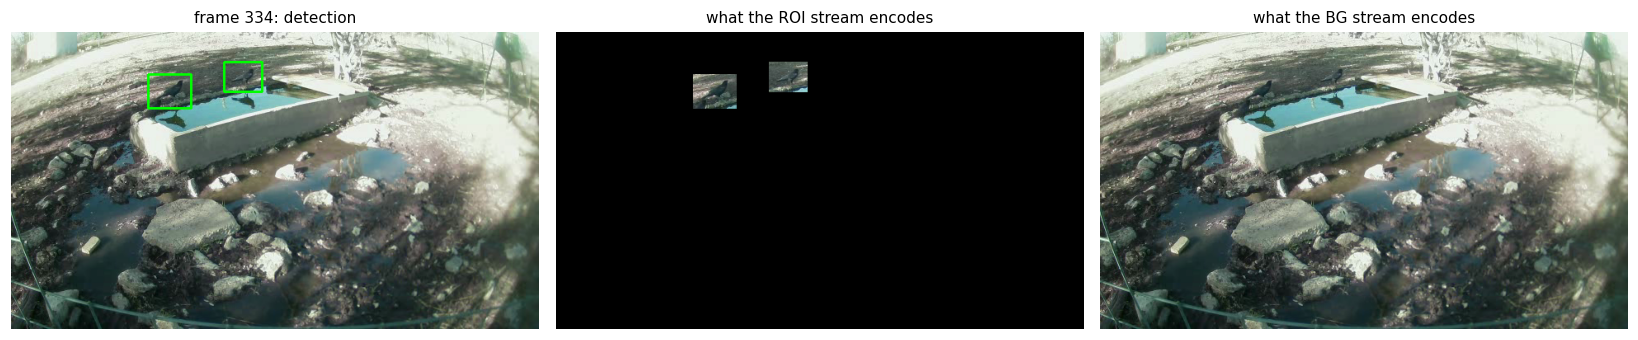

The subject covers about 1.6% of the frame. Everything else is coded once, cheaply, on a sparse schedule.


In [5]:
multi_subject = [
    i for i in selection["roi_kept_frames"]
    if len(boxes_for_frame(detections["frames"], i)) >= 2
]
candidates = multi_subject or selection["roi_kept_frames"]
idx = candidates[len(candidates) // 2]
boxes = boxes_for_frame(detections["frames"], idx)

annotated = original[idx].copy()
for box in boxes:
    x1, y1, x2, y2 = (int(box[k]) for k in ("x1", "y1", "x2", "y2"))
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

frame_height, frame_width = original[idx].shape[:2]
mask = build_boxes_mask(width=frame_width, height=frame_height, boxes=boxes, roi_min_conf=0.0)
roi_view = np.zeros_like(original[idx])
roi_view[mask > 0] = original[idx][mask > 0]

show([annotated, roi_view, original[idx]],
     [f"frame {idx}: detection", "what the ROI stream encodes", "what the BG stream encodes"])

area = np.mean([
    sum((int(b["x2"]) - int(b["x1"])) * (int(b["y2"]) - int(b["y1"])) for b in bs) / (frame_width * frame_height)
    for bs in (boxes_for_frame(detections["frames"], i) for i in range(0, total, 10))
    if bs
])
print(f"The subject covers about {area * 100:.1f}% of the frame. "
      "Everything else is coded once, cheaply, on a sparse schedule.")

## 3. Decompress

The server decodes both streams, interpolates the background frames that were dropped, and composites the subject back over the background.

decoding streams


decoded 627 frames at 640x360

627 frames at 640x360, 30 fps -- the full timeline is back.


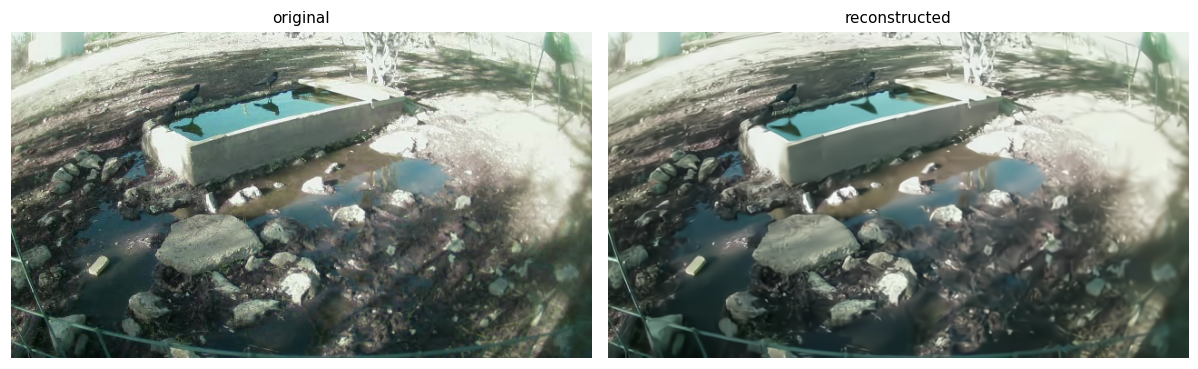

In [6]:
decompression_cfg = yaml.safe_load((ROOT / "configs" / "decompression.yaml").read_text())

decoded = stages.decompress(WORK / "clip.zip", decompression_cfg, progress=print)
print(f"\n{len(decoded.frames)} frames at {decoded.width}x{decoded.height}, "
      f"{decoded.fps:.0f} fps -- the full timeline is back.")

free_gpu()
show([original[idx], decoded.frames[idx]], ["original", "reconstructed"], figsize=(11, 5))

### Does the ROI stream actually help?

Comparing the subject region against the background region would measure scene content, not coding quality. The honest comparison is the same region decoded with and without the ROI stream composited over it.

Inside the subject box, averaged over 63 frames:
  background stream only      26.26 dB
  with the ROI stream         31.01 dB
  gain from the ROI stream    +4.76 dB


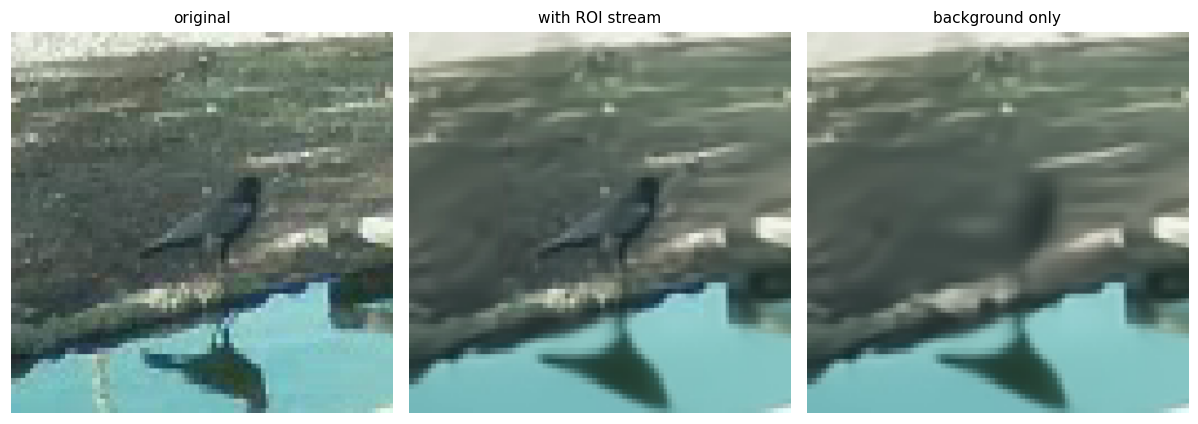

In [7]:
from faunacodec.archive import write_archive

without_roi = write_archive(
    roi_bin=payloads["roi.bin"],
    bg_bin=payloads["bg.bin"],
    meta=meta,
    roi_detections={**detections, "frames": {}},   # no boxes, so nothing gets composited
    frame_drop=selection,
)
background_only = stages.decompress(without_roi, decompression_cfg).frames
free_gpu()

with_roi, plain = [], []
for i in range(0, min(len(original), len(decoded.frames), len(background_only)), 10):
    bs = boxes_for_frame(detections["frames"], i)
    if not bs:
        continue
    x1, y1, x2, y2 = (int(bs[0][k]) for k in ("x1", "y1", "x2", "y2"))
    if x2 - x1 < 8 or y2 - y1 < 8:
        continue
    with_roi.append(psnr(original[i][y1:y2, x1:x2], decoded.frames[i][y1:y2, x1:x2]))
    plain.append(psnr(original[i][y1:y2, x1:x2], background_only[i][y1:y2, x1:x2]))

print(f"Inside the subject box, averaged over {len(with_roi)} frames:")
print(f"  background stream only      {np.mean(plain):.2f} dB")
print(f"  with the ROI stream         {np.mean(with_roi):.2f} dB")
print(f"  gain from the ROI stream    {np.mean(with_roi) - np.mean(plain):+.2f} dB")

x1, y1, x2, y2 = (int(boxes[0][k]) for k in ("x1", "y1", "x2", "y2"))
pad = 20


def crop(frame):
    "Zoom in on the subject, nearest-neighbour so the coding differences stay visible."
    window = frame[max(0, y1 - pad):y2 + pad, max(0, x1 - pad):x2 + pad]
    return cv2.resize(window, (240, 240), interpolation=cv2.INTER_NEAREST)


show([crop(original[idx]), crop(decoded.frames[idx]), crop(background_only[idx])],
     ["original", "with ROI stream", "background only"], figsize=(11, 4))

## 4. Restore (optional)

RestoreUNet is a diffusion U-Net with temporal attention, trained on pairs of clean and round-tripped frames to remove this codec's artifacts specifically. It is deliberately conservative: it starts denoising from a low timestep so it stays faithful to its input rather than inventing detail.

In [8]:
restoration_cfg = yaml.safe_load((ROOT / "configs" / "restoration.yaml").read_text())
checkpoint = ROOT / restoration_cfg["model"]["checkpoint"]

SAMPLE = 24   # restoration is slow; a short excerpt is enough to see the effect

if checkpoint.exists():
    restored = stages.restore(
        decoded.frames[:SAMPLE], restoration_cfg,
        detections=decoded.detections, width=decoded.width, height=decoded.height,
        progress=print,
    )
    free_gpu()
    show([original[0], decoded.frames[0], restored[0]],
         ["original", "reconstructed", "restored"])
else:
    restored = None
    print(f"Skipping: {checkpoint} not found.")
    print("Fetch it with: python scripts/download_models.py --group restore")

Skipping: /home/vangelis/Temp/FaunaCodec/checkpoints/restore_l1/best.pt not found.
Fetch it with: python scripts/download_models.py --group restore


## 5. Upscale (optional)

The upscaling stage is replaceable: one backend runs per invocation. `bicubic` adds no detail and is the fidelity reference. The diffusion backends (`s3diff`, `osediff`, `pid`) are sharper to the eye but synthesize detail that was never captured, so full-reference and no-reference metrics rank them in opposite orders.

**A generative upscale is a perceptual aid, not photometric evidence.** It can invent markings a viewer would read as a diagnostic cue.

In [9]:
frames = restored if restored is not None else decoded.frames[:SAMPLE]

upscaled = stages.upscale(
    frames, "bicubic",
    {"out_w": decoded.width * 2, "out_h": decoded.height * 2},
    progress=print,
)
print(f"{decoded.width}x{decoded.height} -> {upscaled[0].shape[1]}x{upscaled[0].shape[0]}")

from faunacodec.upscaling import UPSCALER_BACKENDS
print("\nAvailable backends:", ", ".join(UPSCALER_BACKENDS))

upscaling with bicubic
640x360 -> 1280x720

Available backends: bicubic, s3diff, osediff, pid, wan, cogvideo


## 6. Save the outputs

In [10]:
from faunacodec.video_io import write_video

written = {
    "reconstructed.mp4": (decoded.frames, decoded.fps),
    "upscaled.mp4": (upscaled, decoded.fps),
}
if restored is not None:
    written["restored.mp4"] = (restored, decoded.fps)

for name, (seq, rate) in written.items():
    path = write_video(seq, WORK / name, fps=rate)
    print(f"{path.relative_to(ROOT)}  ({path.stat().st_size / 1e6:.2f} MB)")

outputs/notebook_demo/reconstructed.mp4  (2.65 MB)
outputs/notebook_demo/upscaled.mp4  (0.27 MB)


## Equivalent command line

```bash
faunacodec-pipeline data/bird1.mp4 --stages compress decompress restore upscale \
                    --upscaler bicubic --save-intermediate
```

Or the two halves separately, as a deployment would:

```bash
faunacodec-compress   data/bird1.mp4 --resolution 640x360 -o clip.zip   # edge
faunacodec-decompress clip.zip -o reconstructed.mp4                     # server
```

### One thing to watch out for

DCVC's floating-point entropy coder is **not bit-exact across CPU architectures**. An archive encoded on an ARM edge device decodes into noise on an x86 server, silently. FaunaCodec records the encoder's architecture and warns you at decode time. Use the deterministic integer runtime in `third_party/dcvc_int16/`, or a block codec (`compression.codec: av1`), when the two ends differ. See the README for what the corruption looks like.